In [1]:
# %pip install kagglehub
# %pip install neo4j python-dotenv tqdm pandas

In [2]:
import kagglehub
import pandas as pd
import os

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# create output directory if it doesn't exist
output_Path = "D:/tierra/outputs/neo4j/"
os.makedirs(output_Path, exist_ok=True)

# mexico dataset
mexico_dataset = "D:/tierra/datasets/mexico_orgc_dataset_complete.csv"
mexico = pd.read_csv(mexico_dataset)

# Create profile_id based on unique combinations of location and date
mexico['profile_id'] = mexico.groupby(['latitude', 'longitude', 'date']).ngroup().apply(lambda x: str(x + 1).zfill(5))
mexico = mexico[['profile_id'] + [col for col in mexico.columns if col != 'profile_id']]

# rename columns
mexico.rename(columns={'geometry': 'location'}, inplace=True)

# drop columns
mexico.drop(columns=['longitude', 'latitude'], inplace=True)

# drop missing values
mexico.dropna(inplace=True)

# drop duplicates
mexico.drop_duplicates(inplace=True)

ecoregions = {
       1: 'Tropical húmeda',
       2: 'Tropical subhúmeda',
       3: 'Templada húmeda',
       4: 'Templada subhúmeda',
       5: 'Árida y semiárida',
       7: 'Inundable o Transición tierra-mar'
}

lancovers = {
       1:'Evergreen Needleleaf Forests',
       2:'Evergreen Broadleaf Forests',
       3:'Deciduous Needleleaf Forests',
       4:'Deciduous Broadleaf Forests',
       5:'Mixed Forests',
       6:'Closed Shrublands',
       7:'Open Shrublands',
       8:'Woody Savannas',
       9:'Savannas',
       10:'Grasslands',
       11:'Permanent Wetlands',
       12:'Croplands',
       13:'Urban and Built-up Lands',
       14:'Cropland/Natural Vegetation Mosaics',
       15:'Permanent Snow and Ice',
       16:'Barren',
       17:'Water Bodies',
       255:'Unclassified'
}

# replace ecoregion and landcover codes with names
mexico['ecoregion'] = mexico['ecoregion'].replace(ecoregions)
mexico['landcover'] = mexico['landcover'].replace(lancovers)

# order by profile_id
mexico.sort_values(by='profile_id', inplace=True)

# reset index
mexico.reset_index(drop=True, inplace=True)

print(f"Columns in dataset: {mexico.columns}")
print(f"Shape of dataset: {mexico.shape}")

# display dataset
mexico.head()

d:\tierra\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Columns in dataset: Index(['profile_id', 'date', 'upper_depth', 'lower_depth', 'clay', 'elcosp',
       'orgc', 'phaq', 'sand', 'silt', 'temperature', 'precipitation',
       'landcover', 'ecoregion', 'location', 'slope_mean', 'soil_type',
       'bedrock'],
      dtype='object')
Shape of dataset: (2990, 18)


,profile_id,date,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,temperature,precipitation,landcover,ecoregion,location,slope_mean,soil_type,bedrock
0,00001,5/18/2004,0,18,7.0,0.0,7.0,6.4,84.0,9.0,16.675776,147.141876,Evergreen Broadleaf Forests,Inundable o Transición tierra-mar,POINT (-92.441025 14.737815000000001),0.153699,REGOSOL EUTRICO,rocas_igneas
1,00002,5/20/2004,0,25,28.0,0.1,36.0,7.0,22.0,50.0,16.675776,147.141876,Woody Savannas,Tropical húmeda,POINT (-92.53133 14.853713000000004),0.153699,GLEYSOL VERTICO,rocas_igneas
2,00003,5/19/2004,0,10,10.0,0.2,10.0,6.0,74.0,16.0,16.675776,147.141876,Woody Savannas,Tropical húmeda,POINT (-92.32616 14.895821000000002),0.914337,FLUVISOL EUTRICO,rocas_igneas
3,00003,5/19/2004,10,28,8.0,0.0,2.0,6.0,80.0,12.0,16.675776,147.141876,Woody Savannas,Tropical húmeda,POINT (-92.32616 14.895821000000002),0.914337,FLUVISOL EUTRICO,rocas_igneas
4,00004,5/21/2004,0,25,24.0,0.1,27.0,7.1,29.0,47.0,16.675776,147.141876,Savannas,Tropical húmeda,POINT (-92.44349 14.898544999999997),0.153699,FEOZEM HAPLICO,rocas_igneas


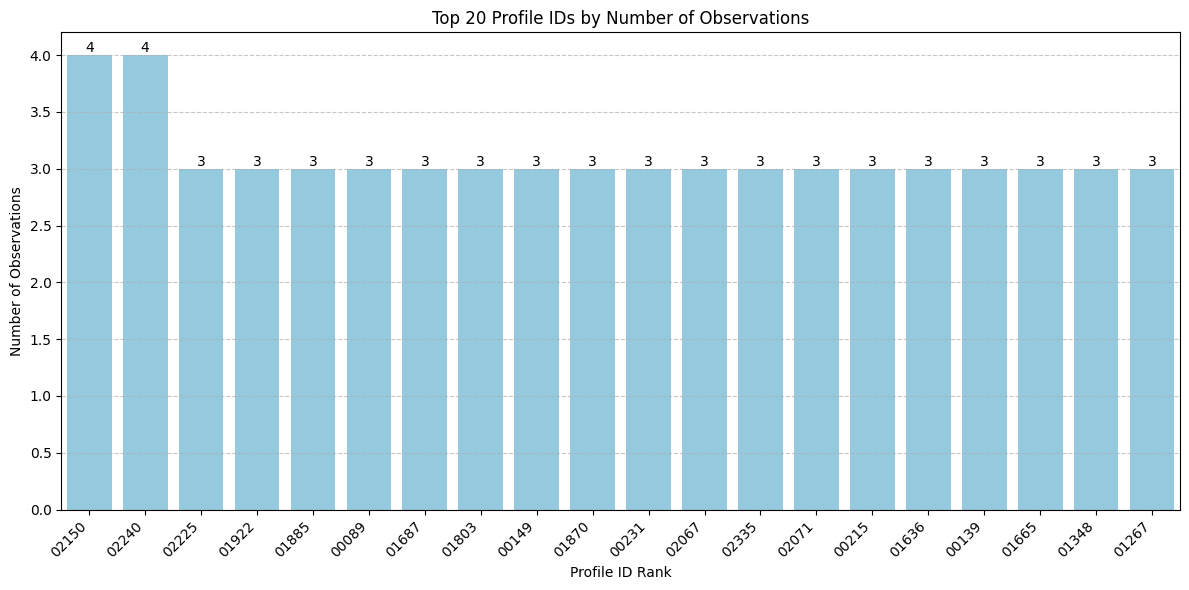


Profile ID Summary:
Total profiles: 2,386
Maximum observations/profile: 4
Average observations/profile: 1.25


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a plot to show profile_id repetitions
plt.figure(figsize=(12, 6))

# Use the already calculated profile_counts from previous cell
profile_counts = mexico['profile_id'].value_counts()
sns.barplot(x=range(20), y=profile_counts.head(20), color='skyblue')

# Customize the plot
plt.title('Top 20 Profile IDs by Number of Observations', fontsize=12)
plt.xlabel('Profile ID Rank', fontsize=10)
plt.ylabel('Number of Observations', fontsize=10)

# Add profile IDs as x-tick labels
plt.xticks(range(20), profile_counts.head(20).index, rotation=45, ha='right')

# Add value labels on top of each bar
for idx, value in enumerate(profile_counts.head(20)):
    plt.text(idx, value, str(value), ha='center', va='bottom')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print summary using f-strings for better formatting
print("\nProfile ID Summary:")
print(f"Total profiles: {len(profile_counts):,}")
print(f"Maximum observations/profile: {profile_counts.max():,}")
print(f"Average observations/profile: {profile_counts.mean():.2f}")

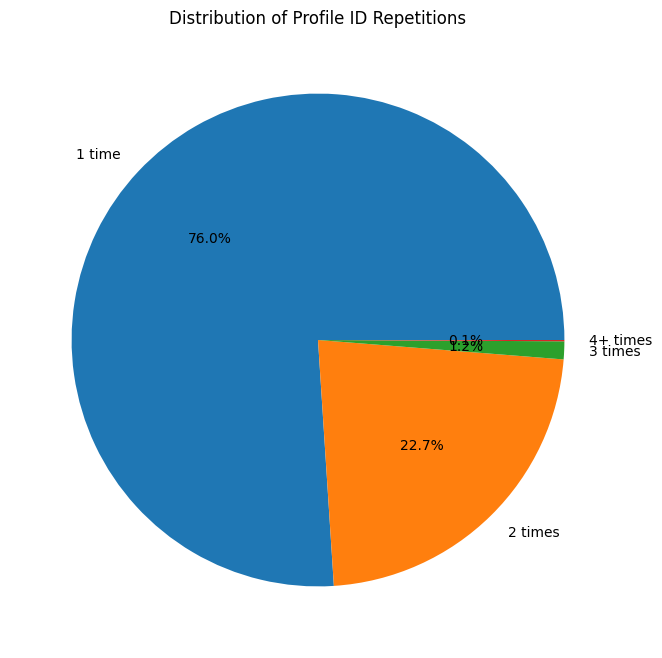


Detailed breakdown:
Profiles repeated 1 time: 1814
Profiles repeated 2 times: 542
Profiles repeated 3 times: 28
Profiles repeated 4+ times: 2


In [4]:
# Calculate counts of profile_id frequencies
freq_counts = profile_counts.value_counts().sort_index()

# Create labels and values for pie chart
labels = ['1 time', '2 times', '3 times', '4+ times']
values = [
    freq_counts.get(1, 0),  # Count of profiles appearing 1 time
    freq_counts.get(2, 0),  # Count of profiles appearing 2 times 
    freq_counts.get(3, 0),  # Count of profiles appearing 3 times
    sum(freq_counts[freq_counts.index >= 4])  # Count of profiles appearing 4+ times
]

plt.figure(figsize=(10, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Profile ID Repetitions')
plt.show()

print("\nDetailed breakdown:")
for label, value in zip(labels, values):
    print(f"Profiles repeated {label}: {value}")

In [5]:
# save the dataset to a csv file to import into neo4j
path_saved = os.path.join(output_Path, 'dataset_orgc.csv')
mexico.to_csv(path_saved, index=False, header=True)
print(f"Master Dataset saved to {path_saved}")

# keep only columns for observation set
path_obs = os.path.join(output_Path, 'dataset_obs.csv')
cols_obs = ['profile_id', 'date', 'location', 'upper_depth', 'lower_depth']
mexico_obs = mexico[cols_obs].copy()

# save the dataset to a csv file to import into neo4j
path_obs_saved = os.path.join(output_Path, 'dataset_obs.csv')
mexico_obs.to_csv(path_obs_saved, index=False, header=True)
print(f"Observation Dataset saved to {path_obs_saved}")

# keep only columns for soil_properties set
path_soil = os.path.join(output_Path, 'dataset_soil.csv')
cols_soil = ['profile_id', 'clay', 'elcosp', 'orgc', 'phaq', 'sand', 'silt', 'temperature', 'precipitation', 'landcover', 'ecoregion', 'slope_mean', 'soil_type', 'bedrock']
mexico_soil = mexico[cols_soil].copy()

# save the dataset to a csv file to import into neo4j
path_soil_saved = os.path.join(output_Path, 'dataset_soil.csv')
mexico_soil.to_csv(path_soil_saved, index=False, header=True)
print(f"Soil Properties Dataset saved to {path_soil_saved}")

Master Dataset saved to D:/tierra/outputs/neo4j/dataset_orgc.csv
Observation Dataset saved to D:/tierra/outputs/neo4j/dataset_obs.csv
Soil Properties Dataset saved to D:/tierra/outputs/neo4j/dataset_soil.csv


In [6]:
# load from dot env file
import os
from dotenv import load_dotenv
load_dotenv()

load_dotenv()
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_URI = os.getenv("NEO4J_URI")

In [7]:
from neo4j import GraphDatabase
uri = NEO4J_URI
username = NEO4J_USERNAME
password = NEO4J_PASSWORD
driver = GraphDatabase.driver(uri, auth=(username, password))
try:
   driver.verify_connectivity()
   print("Connection successful!")
except Exception as e:
   print(f"Failed to connect to Neo4j: {e}")

Connection successful!


In [8]:
# %pip install rdflib neo4j pyvis

In [9]:
# CAUTION: This will delete all nodes and relationships in the database
# Make sure to back up your data if necessary
def reset_database():
    with driver.session() as session:
        session.run("MATCH (n) DETACH DELETE n")  # Deletes all nodes and relationships

# Uncomment the following line to reset the database
reset_database()

RDF graph saved to D:/tierra/outputs/neo4j/rdf_schmea.rdf


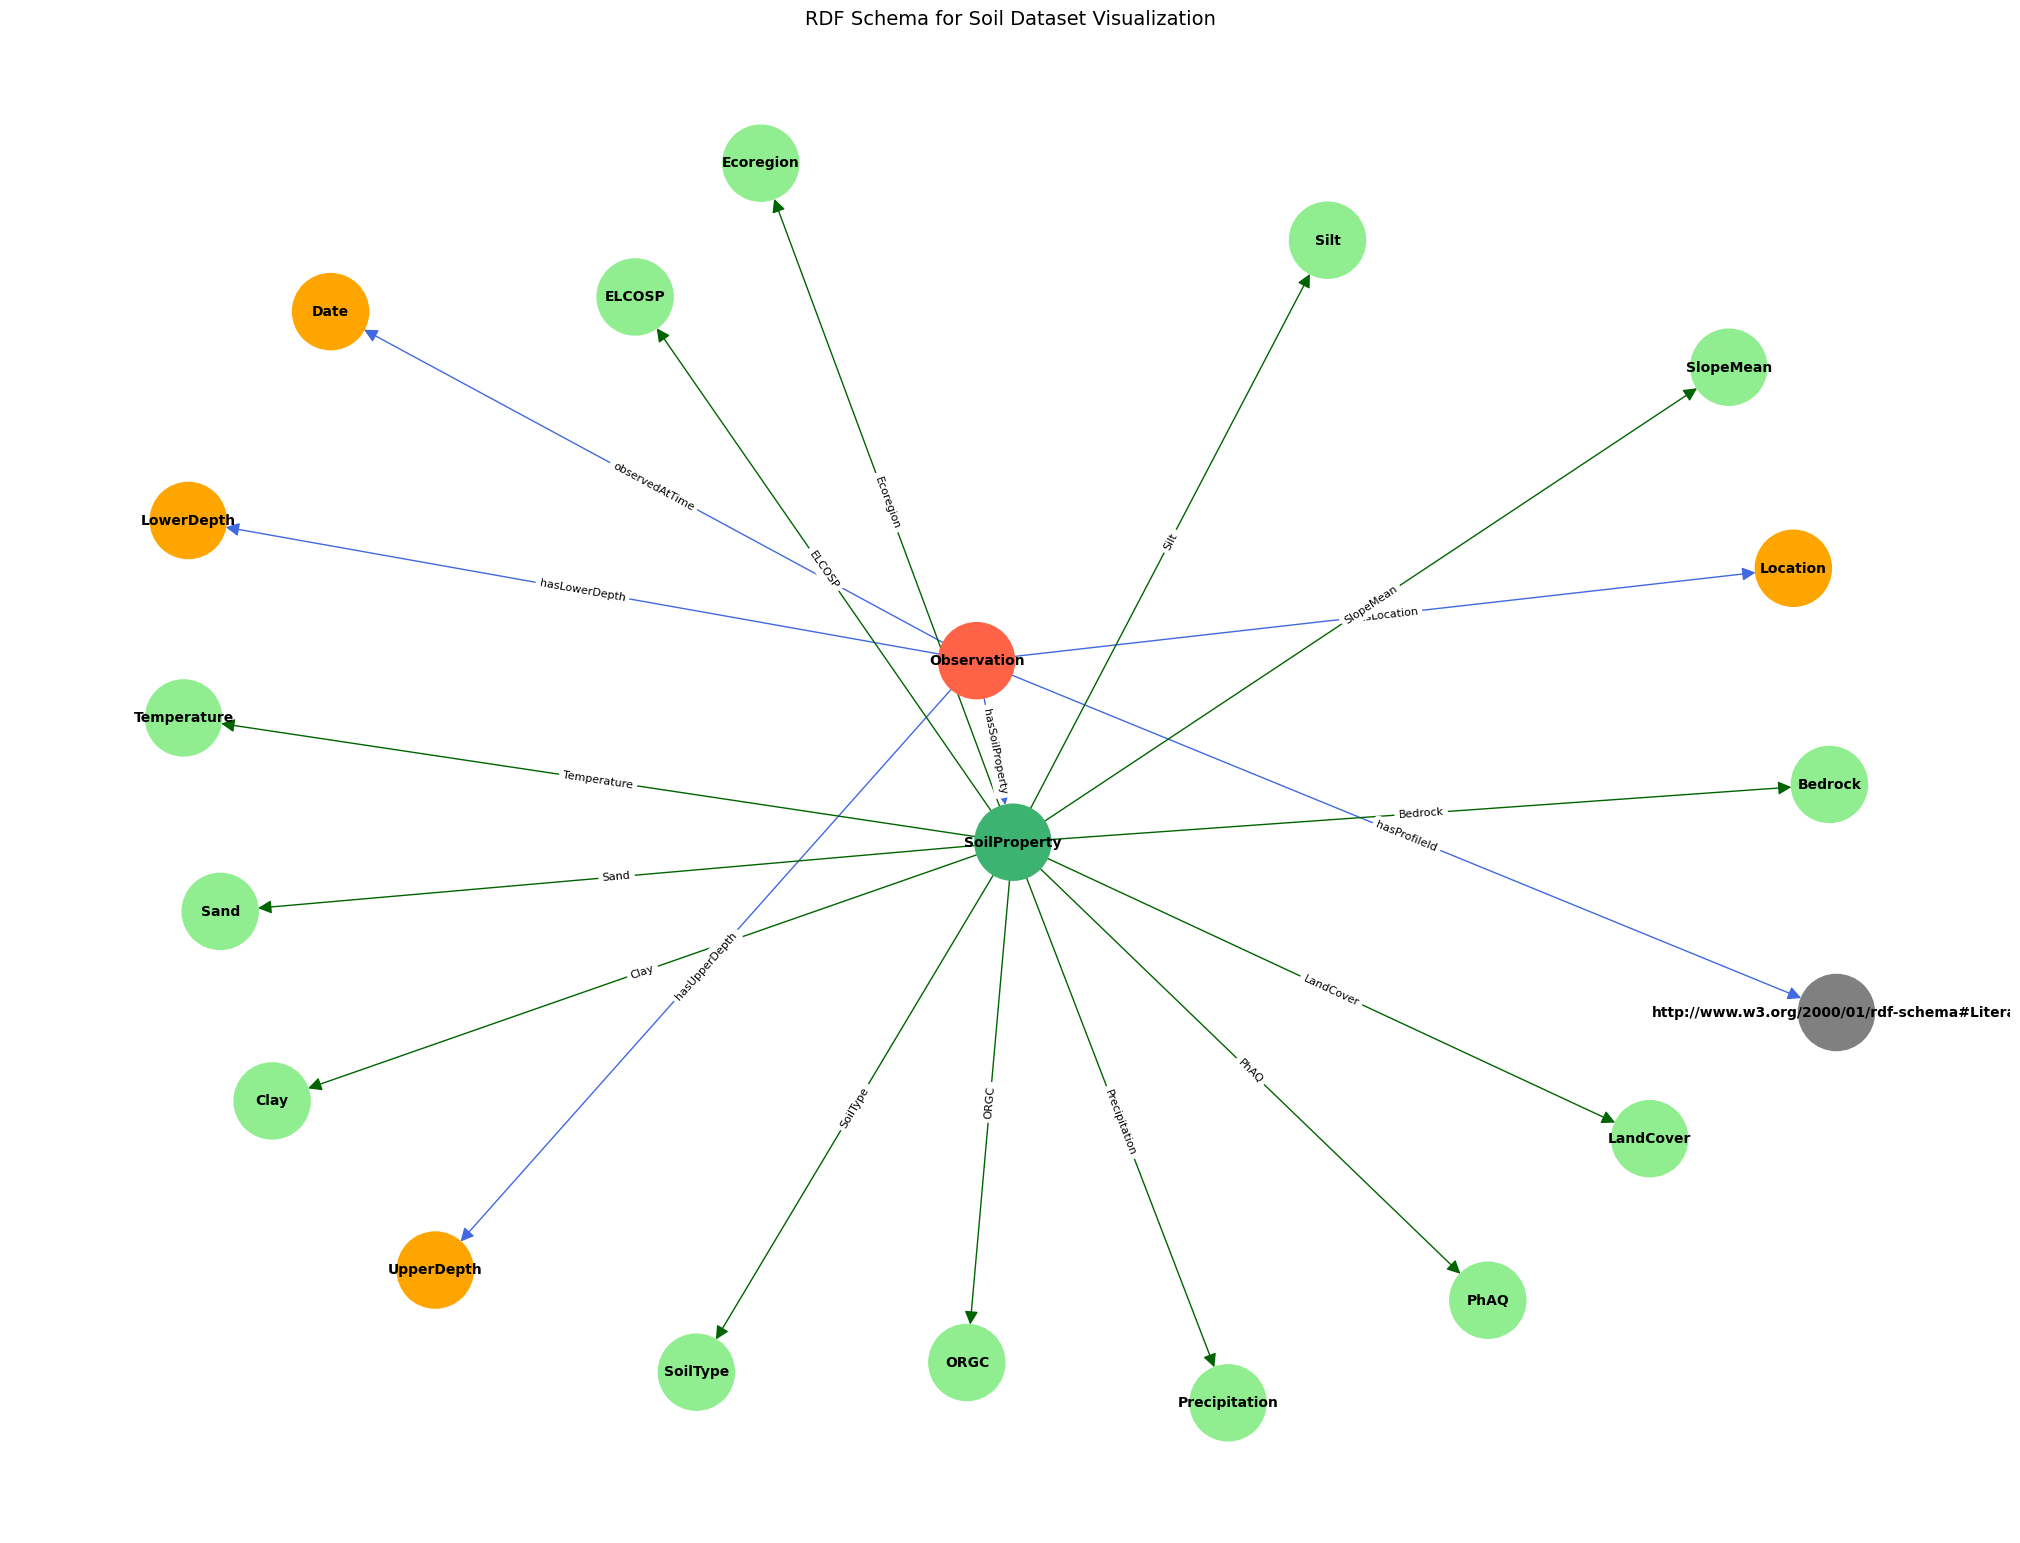

In [10]:
from rdflib import Graph, Namespace, RDF, RDFS, Literal
import networkx as nx
import matplotlib.pyplot as plt

# Define the soil attributes
soil_attributes = {
    'clay': 'Clay',
    'elcosp': 'ELCOSP',
    'orgc': 'ORGC',
    'phaq': 'PhAQ',
    'sand': 'Sand',
    'silt': 'Silt',
    'temperature': 'Temperature',
    'precipitation': 'Precipitation',
    'landcover': 'LandCover',
    'ecoregion': 'Ecoregion',
    'slope_mean': 'SlopeMean',
    'soil_type': 'SoilType',
    'bedrock': 'Bedrock'
}

def build_rdf_schema(show_child=False):
    EX = Namespace("http://example.org/soil#")
    TIME = Namespace("http://www.w3.org/2006/time#")
    GEO = Namespace("http://www.opengis.net/ont/geosparql#")

    g = Graph()
    g.bind("ex", EX)
    g.bind("time", TIME)
    g.bind("geo", GEO)

    # Define Classes
    classes = ['Observation', 'Location', 'UpperDepth', 'LowerDepth', 'SoilProperty']
    for cls in classes:
        g.add((EX[cls], RDF.type, RDFS.Class))
    g.add((TIME['Date'], RDF.type, RDFS.Class))
    g.add((GEO['Location'], RDF.type, RDFS.Class))

    # add date and location to classes
    classes.extend(['Date', 'Location'])

    # Define Object Properties: map of (property_name, domain, range)
    obj_properties = [
        ('hasLocation', 'Observation', 'Location'),
        ('hasUpperDepth', 'Observation', 'UpperDepth'),
        ('hasLowerDepth', 'Observation', 'LowerDepth'),
        ('hasSoilProperty', 'Observation', 'SoilProperty'),
        ('hasProfileId', 'Observation', RDFS.Literal),
        ('observedAtTime', 'Observation', 'Date')
    ]
    for prop, domain, range_ in obj_properties:
        g.add((EX[prop], RDF.type, RDF.Property))
        g.add((EX[prop], RDFS.domain, EX[domain]))
        g.add((EX[prop], RDFS.range, EX[range_]))

    # Define Datatype Properties for SoilProperty
    for attr, prop in soil_attributes.items():
        g.add((EX[prop], RDF.type, RDF.Property))
        g.add((EX[prop], RDFS.domain, EX.SoilProperty))
        g.add((EX[prop], RDFS.range, RDFS.Literal))

    # Save RDF graph
    rdf_file_path = os.path.join(output_Path, 'rdf_schmea.rdf')
    g.serialize(destination=rdf_file_path, format='xml')
    print(f"RDF graph saved to {rdf_file_path}")

    # Build NetworkX visualization graph
    G = nx.DiGraph()

    # Add class nodes
    for cls in classes:
        G.add_node(cls)

    # Add object property edges
    for prop, domain, range_ in obj_properties:
        G.add_edge(domain, range_, label=prop)

    if show_child:
        for attr_label in soil_attributes.values():
            G.add_node(attr_label)
            G.add_edge('SoilProperty', attr_label, label=attr_label)

    return G, classes

def visualise_graph(G, classes, title, soil_attributes=soil_attributes):
    node_colors = []
    for node in G.nodes():
        if node == "Observation":
            node_colors.append("tomato")
        elif node == "SoilProperty":
            node_colors.append("mediumseagreen")
        elif node in classes:
            node_colors.append("orange")
        elif node in soil_attributes.values():
            node_colors.append("lightgreen")
        else:
            node_colors.append("gray")

    edge_colors = []
    for u, _ in G.edges():
        if u == "Observation":
            edge_colors.append("royalblue")
        elif u == "SoilProperty":
            edge_colors.append("darkgreen")
        else:
            edge_colors.append("gray")

    pos = nx.spring_layout(G, seed=42, k=1.5)

    plt.figure(figsize=(20, 15))
    nx.draw(
        G, pos, with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=3000,
        font_size=10,
        font_weight='bold',
        arrowsize=20
    )

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(f"RDF Schema for Soil Dataset {title}", fontsize=14)
    plt.show()

G, classes = build_rdf_schema(show_child=True)
visualise_graph(G, classes, "Visualization")

In [11]:
from neo4j import GraphDatabase

soil_attributes = {
    'clay': 'Clay',
    'elcosp': 'ELCOSP',
    'orgc': 'ORGC',
    'phaq': 'PhAQ',
    'sand': 'Sand',
    'silt': 'Silt',
    'temperature': 'Temperature',
    'precipitation': 'Precipitation',
    'landcover': 'LandCover',
    'ecoregion': 'Ecoregion',
    'slope_mean': 'SlopeMean',
    'soil_type': 'SoilType',
    'bedrock': 'Bedrock'
}

classes = ['Observation', 'Location', 'UpperDepth', 'LowerDepth', 'SoilProperty', 'Date']

# Object properties (relationship name, start node, end node)
object_properties = [
    ('HAS_LOCATION', 'Observation', 'Location'),
    ('HAS_UPPER_DEPTH', 'Observation', 'UpperDepth'),
    ('HAS_LOWER_DEPTH', 'Observation', 'LowerDepth'),
    ('HAS_PROFILE_ID', 'Observation', 'ProfileId'),  # ProfileId as literal node
    ('OBSERVED_AT_TIME', 'Observation', 'Date'),
    ('HAS_SOIL_PROPERTY', 'Observation', 'SoilProperty')
]

def create_schema(driver):
    with driver.session() as session:
        # Create class nodes
        for cls in classes:
            session.run("MERGE (c:Class {name: $name})", name=cls)

        # Create literal node for ProfileId
        session.run("MERGE (c:Literal {name: 'ProfileId'})")

        # Create object property relationships
        for rel_name, start, end in object_properties:
            label_start = "Class" if start != "ProfileId" else "Literal"
            label_end = "Class" if end != "ProfileId" else "Literal"
            session.run(f"""
                MATCH (a:{label_start} {{name: $start}}), (b:{label_end} {{name: $end}})
                MERGE (a)-[:{rel_name}]->(b)
            """, start=start, end=end)
            print(f"{start} - {rel_name} -> {end}")

        # Create attributes as nodes under SoilProperty
        for attr_key, attr_label in soil_attributes.items():
            session.run("""
                MATCH (sp:Class {name: 'SoilProperty'})
                MERGE (attr:Attribute {name: $attr_label})
                MERGE (sp)-[:HAS_ATTRIBUTE]->(attr)
            """, attr_label=attr_label)
            print(f"SoilProperty - HAS_ATTRIBUTE -> {attr_label}")

    print("Schema creation completed.")


create_schema(driver)

Observation - HAS_LOCATION -> Location
Observation - HAS_UPPER_DEPTH -> UpperDepth
Observation - HAS_LOWER_DEPTH -> LowerDepth
Observation - HAS_PROFILE_ID -> ProfileId
Observation - OBSERVED_AT_TIME -> Date
Observation - HAS_SOIL_PROPERTY -> SoilProperty
SoilProperty - HAS_ATTRIBUTE -> Clay
SoilProperty - HAS_ATTRIBUTE -> ELCOSP
SoilProperty - HAS_ATTRIBUTE -> ORGC
SoilProperty - HAS_ATTRIBUTE -> PhAQ
SoilProperty - HAS_ATTRIBUTE -> Sand
SoilProperty - HAS_ATTRIBUTE -> Silt
SoilProperty - HAS_ATTRIBUTE -> Temperature
SoilProperty - HAS_ATTRIBUTE -> Precipitation
SoilProperty - HAS_ATTRIBUTE -> LandCover
SoilProperty - HAS_ATTRIBUTE -> Ecoregion
SoilProperty - HAS_ATTRIBUTE -> SlopeMean
SoilProperty - HAS_ATTRIBUTE -> SoilType
SoilProperty - HAS_ATTRIBUTE -> Bedrock
Schema creation completed.


In [12]:
import networkx as nx
import matplotlib.pyplot as plt

def fetch_graph_data(driver, query):
    nodes = {}
    edges = []

    with driver.session() as session:
        results = session.run(query)
        for record in results:
            for rel in record['p'].relationships:
                start_node = rel.start_node
                end_node = rel.end_node
                rel_type = rel.type

                # Add nodes
                nodes[start_node.id] = dict(start_node.items())
                nodes[end_node.id] = dict(end_node.items())

                # Add edge
                edges.append((start_node.id, end_node.id, rel_type))

    return nodes, edges

def plot_graph(nodes, edges, title):
    plt.figure(figsize=(15, 10))

    G = nx.DiGraph()

    for node_id, attrs in nodes.items():
        label = attrs.get('name', f'Node{node_id}')
        G.add_node(node_id, label=label)

    for start, end, rel_type in edges:
        G.add_edge(start, end, label=rel_type)

    pos = nx.spring_layout(G, seed=42, k=1.5)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='lightblue')

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20)

    # Draw node labels
    node_labels = {node: data['label'] for node, data in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10)

    # Draw edge labels
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.show()

Fetched 20 nodes and 19 edges.


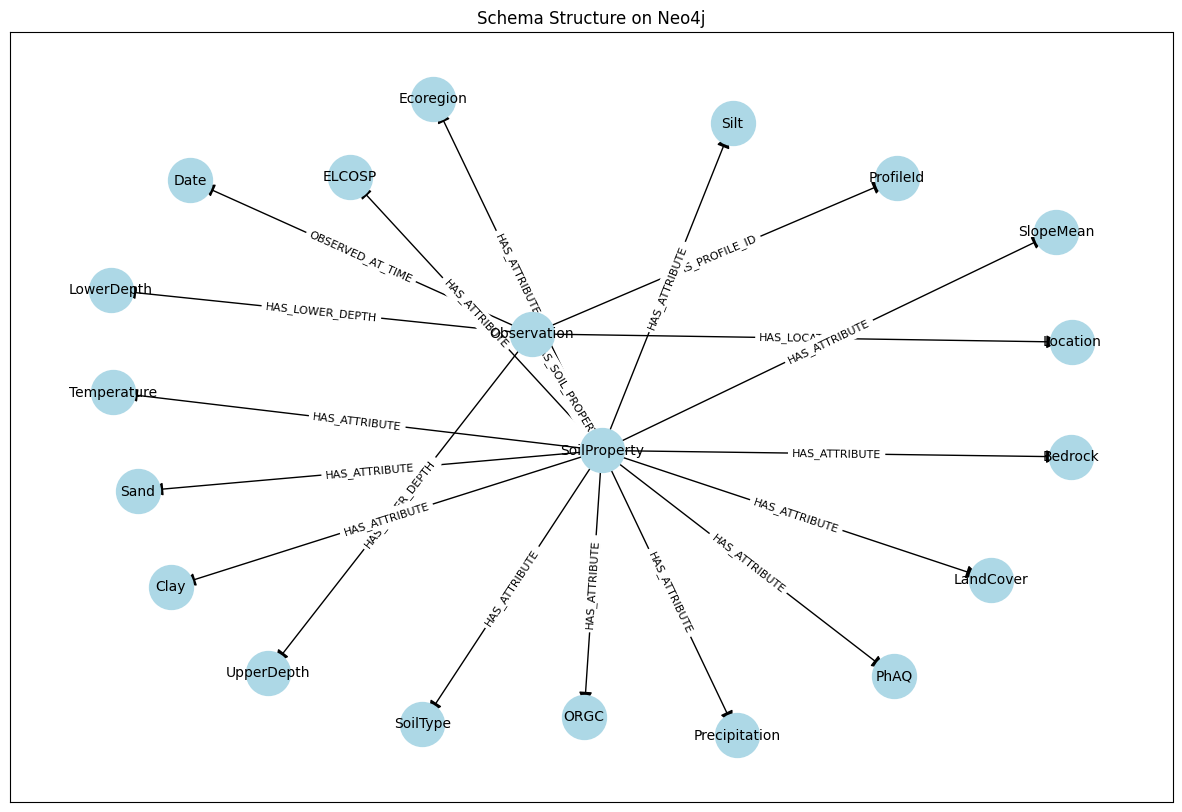

In [13]:
query = "MATCH p=()-[]->() RETURN p LIMIT 25"
nodes, edges = fetch_graph_data(driver, query)

print(f"Fetched {len(nodes)} nodes and {len(edges)} edges.")

plot_graph(nodes, edges, "Schema Structure on Neo4j")

In [15]:
def create_constraints(driver):
    with driver.session() as session:
        # Create constraints to ensure uniqueness
        constraints = [
            "CREATE CONSTRAINT IF NOT EXISTS FOR (o:Observation) REQUIRE o.profile_id IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (l:Location) REQUIRE l.coordinates IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (d:Date) REQUIRE d.value IS UNIQUE"
        ]
        for constraint in constraints:
            try:
                session.run(constraint)
            except Exception as e:
                print(f"Constraint already exists or error: {e}")

def upload_data(driver, mexico_obs, mexico_soil):
    create_constraints(driver)
    
    with driver.session() as session:
        # Process in batches to avoid memory issues
        batch_size = 100
        total_rows = len(mexico_obs)
        
        for i in range(0, total_rows, batch_size):
            batch_obs = mexico_obs.iloc[i:i+batch_size]
            batch_soil = mexico_soil.iloc[i:i+batch_size]
            
            for _, (obs_row, soil_row) in enumerate(zip(batch_obs.iterrows(), batch_soil.iterrows())):
                obs_data = obs_row[1]
                soil_data = soil_row[1]
                
                # Create Observation node with its relationships
                query = """
                MERGE (o:Observation {profile_id: $profile_id})
                
                MERGE (l:Location {coordinates: $location})
                MERGE (o)-[:HAS_LOCATION]->(l)
                
                MERGE (d:Date {value: $date})
                MERGE (o)-[:OBSERVED_AT_TIME]->(d)
                
                MERGE (ud:UpperDepth {value: $upper_depth})
                MERGE (o)-[:HAS_UPPER_DEPTH]->(ud)
                
                MERGE (ld:LowerDepth {value: $lower_depth})
                MERGE (o)-[:HAS_LOWER_DEPTH]->(ld)
                
                MERGE (sp:SoilProperty {
                    clay: $clay,
                    elcosp: $elcosp,
                    orgc: $orgc,
                    phaq: $phaq,
                    sand: $sand,
                    silt: $silt,
                    temperature: $temperature,
                    precipitation: $precipitation,
                    landcover: $landcover,
                    ecoregion: $ecoregion,
                    slope_mean: $slope_mean,
                    soil_type: $soil_type,
                    bedrock: $bedrock
                })
                MERGE (o)-[:HAS_SOIL_PROPERTY]->(sp)
                """
                
                session.run(query, {
                    'profile_id': obs_data['profile_id'],
                    'location': obs_data['location'],
                    'date': obs_data['date'],
                    'upper_depth': float(obs_data['upper_depth']),
                    'lower_depth': float(obs_data['lower_depth']),
                    'clay': float(soil_data['clay']),
                    'elcosp': float(soil_data['elcosp']),
                    'orgc': float(soil_data['orgc']),
                    'phaq': float(soil_data['phaq']),
                    'sand': float(soil_data['sand']),
                    'silt': float(soil_data['silt']),
                    'temperature': float(soil_data['temperature']),
                    'precipitation': float(soil_data['precipitation']),
                    'landcover': str(soil_data['landcover']),
                    'ecoregion': str(soil_data['ecoregion']),
                    'slope_mean': float(soil_data['slope_mean']),
                    'soil_type': str(soil_data['soil_type']),
                    'bedrock': str(soil_data['bedrock'])
                })
            
            print(f"Processed {min(i + batch_size, total_rows)}/{total_rows} records")

print("Starting data upload...")
upload_data(driver, mexico_obs, mexico_soil)
print("Data upload completed!")

Starting data upload...
Processed 100/2990 records
Processed 200/2990 records
Processed 300/2990 records
Processed 400/2990 records
Processed 500/2990 records
Processed 600/2990 records
Processed 700/2990 records
Processed 800/2990 records
Processed 900/2990 records
Processed 1000/2990 records
Processed 1100/2990 records
Processed 1200/2990 records
Processed 1300/2990 records
Processed 1400/2990 records
Processed 1500/2990 records
Processed 1600/2990 records
Processed 1700/2990 records
Processed 1800/2990 records
Processed 1900/2990 records
Processed 2000/2990 records
Processed 2100/2990 records
Processed 2200/2990 records
Processed 2300/2990 records
Processed 2400/2990 records
Processed 2500/2990 records
Processed 2600/2990 records
Processed 2700/2990 records
Processed 2800/2990 records
Processed 2900/2990 records
Processed 2990/2990 records
Data upload completed!
